#  X-ray Report Generation với BLIP (Fine-tuned)

**Bài 2 — Đề tự chọn:** Fine-tune BLIP cho task sinh report X-quang ngực  
**Dataset:** Indiana University Chest X-rays (`raddar/chest-xrays-indiana-university`)  
**Model:** `Salesforce/blip-image-captioning-base` (~250M params)  
**Mục tiêu:** Cải thiện chất lượng so với baseline DenseNet+LSTM

## Tại sao chọn BLIP thay vì DenseNet+LSTM?

| Tiêu chí | DenseNet + LSTM (cũ) | BLIP fine-tuned (mới) |
|---|---|---|
| Image encoder | CNN (ImageNet pretrained) | Vision Transformer (ViT-B/16) |
| Text decoder | LSTM 1 layer + attention | Transformer 12 layers (BERT-style) |
| Pretraining | Chỉ ảnh (ImageNet) | 129M cặp (ảnh, caption) |
| Cross-modal | Concat features | Cross-attention từng layer |
| Tham số | ~10M (decoder) | ~247M (toàn bộ) |

BLIP đã học được cách "nhìn ảnh và sinh mô tả", ta chỉ cần fine-tune để thích nghi với domain X-quang.


## 1. Cài đặt thư viện

In [1]:
# Pin numpy/pandas cho ổn định
!pip install -q numpy==1.26.4 pandas==2.2.2

# Core: transformers + accelerate cho fp16 training
!pip install -q transformers==4.44.2 accelerate==0.34.2

# Metrics
!pip install -q rouge-score bert-score nltk sacrebleu

# Dataset từ Kaggle
!pip install -q kagglehub

print(" Cài đặt xong. Hãy Restart Runtime trước khi chạy tiếp!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 52.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.

## 2. Mount Google Drive (lưu checkpoint)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/xray_blip"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f" Sẽ lưu model vào: {SAVE_DIR}")

Mounted at /content/drive
 Sẽ lưu model vào: /content/drive/MyDrive/xray_blip


## 3. Tải dataset từ Kaggle

Trước khi chạy cell này, upload file `kaggle.json` vào `/content/` (lấy từ Kaggle  Account  Create New API Token).

In [2]:
import os, shutil

os.makedirs("/root/.kaggle", exist_ok=True)
if os.path.exists("/content/kaggle.json"):
    shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
    print(" Kaggle credentials đã setup")
else:
    print(" Vui lòng upload kaggle.json vào /content/ trước")

import kagglehub
DATA_DIR = kagglehub.dataset_download("raddar/chest-xrays-indiana-university")
print(" Dataset đã tải về:", DATA_DIR)

 Vui lòng upload kaggle.json vào /content/ trước


100%|██████████| 13.2G/13.2G [10:33<00:00, 22.3MB/s]

Extracting files...


 Dataset đã tải về: /root/.cache/kagglehub/datasets/raddar/chest-xrays-indiana-university/versions/2


## 4. Import & cấu hình

In [3]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")

# ===== Đường dẫn =====
CSV_PATH = os.path.join(DATA_DIR, "indiana_reports.csv")
IMG_DIR  = os.path.join(DATA_DIR, "images")

# ===== Hyperparameters =====
MODEL_NAME       = "Salesforce/blip-image-captioning-base"
BATCH_SIZE       = 8         # T4 vừa với fp16
GRAD_ACCUM_STEPS = 2         # effective batch = 16
EPOCHS           = 8         # BLIP hội tụ nhanh hơn LSTM, không cần 30 epoch
LR               = 2e-5      # LR nhỏ vì đang fine-tune model lớn
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1
MAX_LEN          = 128       # max token cho caption
FREEZE_VISION_EPOCHS = 2     # 2 epoch đầu freeze ViT

print("CSV exists:", os.path.exists(CSV_PATH))
print("IMG exists:", os.path.exists(IMG_DIR))

DEVICE: cuda
GPU: Tesla T4
VRAM: 15.64 GB
CSV exists: True
IMG exists: True


## 5. Đọc & làm sạch dữ liệu

In [4]:
df = pd.read_csv(CSV_PATH)
df = df[['uid', 'findings']]
df = df.dropna(subset=['findings'])
df = df[df['findings'].str.strip() != ""]
df = df.reset_index(drop=True)

print("Số report sau khi clean:", len(df))
df.head()

Số report sau khi clean: 3337


,uid,findings
0,1,The cardiac silhouette and mediastinum size ar...
1,2,Borderline cardiomegaly. Midline sternotomy XX...
2,4,There are diffuse bilateral interstitial and a...
3,5,The cardiomediastinal silhouette and pulmonary...
4,6,Heart size and mediastinal contour are within ...


## 6. Map `uid`  đường dẫn ảnh

In [5]:
from collections import defaultdict

all_images = []
for root, dirs, files in os.walk(IMG_DIR):
    for f in files:
        if f.endswith(".png"):
            all_images.append(os.path.join(root, f))
print("Tổng số ảnh:", len(all_images))

uid_to_paths = defaultdict(list)
for p in all_images:
    fname = os.path.basename(p)
    if "_" in fname:
        uid_to_paths[fname.split("_")[0]].append(p)

def get_image_path(uid):
    paths = uid_to_paths.get(str(uid), [])
    return paths[0] if paths else None

df["image_path"] = df["uid"].apply(get_image_path)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)
print("Số sample sau khi map ảnh:", len(df))

Tổng số ảnh: 7470
Số sample sau khi map ảnh: 3337


## 7. Chia Train / Val / Test

Dùng `random_state=42` giống code cũ để có thể so sánh trực tiếp với baseline.

In [6]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

Train: 2669 | Val: 334 | Test: 334


## 8. Load BLIP processor & model

`BlipProcessor` đảm nhận cả việc preprocess ảnh (resize 384×384, normalize) và tokenize text — không cần xây vocab thủ công như code cũ.

In [7]:
processor = BlipProcessor.from_pretrained(MODEL_NAME)
model     = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params/1e6:.1f}M")
print("Vision encoder:", type(model.vision_model).__name__)
print("Text decoder  :", type(model.text_decoder).__name__)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Total parameters: 247.4M
Vision encoder: BlipVisionModel
Text decoder  : BlipTextLMHeadModel


## 9. Test BLIP zero-shot trên 1 ảnh X-quang

Trước khi fine-tune, xem BLIP "vanilla" caption ảnh X-quang ra cái gì. Thường nó sẽ caption rất chung chung (vì pretrain trên ảnh thường, không phải y khoa).

 BLIP zero-shot: a chest with a large, white chest

 Ground truth : Stable enlargement of the cardiac silhouette, lateral view interlobar fissural thickening. Interstitial opacities greatest in the central lungs and bases.


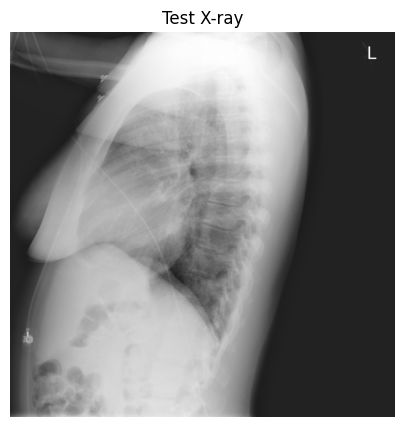

In [8]:
sample_path = test_df.iloc[0]["image_path"]
raw_image   = Image.open(sample_path).convert("RGB")

inputs = processor(raw_image, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    out = model.generate(**inputs, max_length=50)

print(" BLIP zero-shot:", processor.decode(out[0], skip_special_tokens=True))
print("\n Ground truth :", test_df.iloc[0]["findings"][:200])

plt.figure(figsize=(5,5))
plt.imshow(raw_image, cmap='gray')
plt.axis('off')
plt.title("Test X-ray")
plt.show()

## 10. PyTorch Dataset

In [9]:
class XrayBlipDataset(Dataset):
    def __init__(self, dataframe, processor, max_len=128):
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image   = Image.open(row["image_path"]).convert("RGB")
        caption = str(row["findings"]).strip()

        # Processor xử lý cả ảnh và text trong 1 lần
        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        # Bỏ chiều batch=1 do processor thêm vào
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        return encoding

In [10]:
train_ds = XrayBlipDataset(train_df, processor, MAX_LEN)
val_ds   = XrayBlipDataset(val_df,   processor, MAX_LEN)
test_ds  = XrayBlipDataset(test_df,  processor, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check
batch = next(iter(train_loader))
for k, v in batch.items():
    print(f"{k:20s}  {v.shape} ({v.dtype})")

pixel_values          torch.Size([8, 3, 384, 384]) (torch.float32)
input_ids             torch.Size([8, 128]) (torch.int64)
attention_mask        torch.Size([8, 128]) (torch.int64)


## 11. Helper: freeze / unfreeze vision encoder

Chiến lược: 2 epoch đầu chỉ train text decoder (decoder phải học "phong cách viết report" trước), sau đó mở vision encoder để fine-tune cả ViT (vision phải học cách "nhìn X-quang").

In [11]:
def set_vision_trainable(model, trainable: bool):
    for p in model.vision_model.parameters():
        p.requires_grad = trainable

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Phase 1: freeze vision
set_vision_trainable(model, False)
print(f"Phase 1 trainable params: {count_trainable(model)/1e6:.1f}M (vision frozen)")

Phase 1 trainable params: 161.3M (vision frozen)


## 12. Optimizer & scheduler

In [12]:
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

total_steps  = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

scaler = GradScaler()  # mixed precision
print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")

Total steps: 1336 | Warmup: 133


/tmp/ipykernel_7935/2216852923.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # mixed precision


## 13. Validate function

In [13]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss, n = 0.0, 0
    for batch in tqdm(loader, desc="Val", leave=False):
        batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
        with autocast(dtype=torch.float16):
            out = model(
                pixel_values=batch["pixel_values"],
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["input_ids"],
            )
        total_loss += out.loss.item()
        n += 1
    return total_loss / max(n, 1)

## 14. Training loop

**Mỗi epoch ~ 8-12 phút trên T4** (với ~3000 samples train). Tổng 8 epoch ≈ 60-90 phút.

In [14]:
best_val_loss = float("inf")
train_losses, val_losses = [], []

BEST_PATH = os.path.join(SAVE_DIR, "best_blip.pt")

for epoch in range(EPOCHS):
    # === Phase 2: unfreeze vision encoder sau N epoch ===
    if epoch == FREEZE_VISION_EPOCHS:
        set_vision_trainable(model, True)
        # Khởi tạo lại optimizer để bao gồm cả vision params (LR thấp hơn cho vision)
        optimizer = AdamW([
            {"params": model.vision_model.parameters(),  "lr": LR / 10},
            {"params": model.text_decoder.parameters(),  "lr": LR},
        ], weight_decay=WEIGHT_DECAY)
        # Scheduler mới cho phase 2
        remaining_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * (EPOCHS - epoch)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=int(remaining_steps * 0.05),
            num_training_steps=remaining_steps,
        )
        print(f" Unfroze vision encoder | Trainable: {count_trainable(model)/1e6:.1f}M")

    model.train()
    total_loss, n_steps = 0.0, 0
    optimizer.zero_grad()

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for step, batch in enumerate(loop):
        batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}

        with autocast(dtype=torch.float16):
            out = model(
                pixel_values=batch["pixel_values"],
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["input_ids"],   # BLIP tự shift labels
            )
            loss = out.loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += out.loss.item()
        n_steps += 1
        loop.set_postfix(loss=out.loss.item(), lr=scheduler.get_last_lr()[0])

    train_loss = total_loss / max(n_steps, 1)
    val_loss   = validate(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "model_state": model.state_dict(),
            "epoch": epoch + 1,
            "val_loss": val_loss,
        }, BEST_PATH)
        print(f"   Saved best model  {BEST_PATH}")

    # Free GPU memory cache
    torch.cuda.empty_cache()

print(f"\n Training xong. Best val loss: {best_val_loss:.4f}")

Epoch 1/8:   0%|          | 0/334 [00:00<?, ?it/s]

/tmp/ipykernel_7935/1219689022.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):
/tmp/ipykernel_7935/1219689022.py:47: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Val:   0%|          | 0/42 [00:00<?, ?it/s]

/tmp/ipykernel_7935/644872783.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


Epoch 1 | Train: 6.4010 | Val: 2.7478
   Saved best model  /content/drive/MyDrive/xray_blip/best_blip.pt


...

Val:   0%|          | 0/42 [00:00<?, ?it/s]

Epoch 7 | Train: 0.3598 | Val: 0.4972
   Saved best model  /content/drive/MyDrive/xray_blip/best_blip.pt


Epoch 8/8:   0%|          | 0/334 [00:00<?, ?it/s]

Val:   0%|          | 0/42 [00:00<?, ?it/s]

Epoch 8 | Train: 0.3382 | Val: 0.4964
   Saved best model  /content/drive/MyDrive/xray_blip/best_blip.pt

 Training xong. Best val loss: 0.4964


## 15. Vẽ loss curve

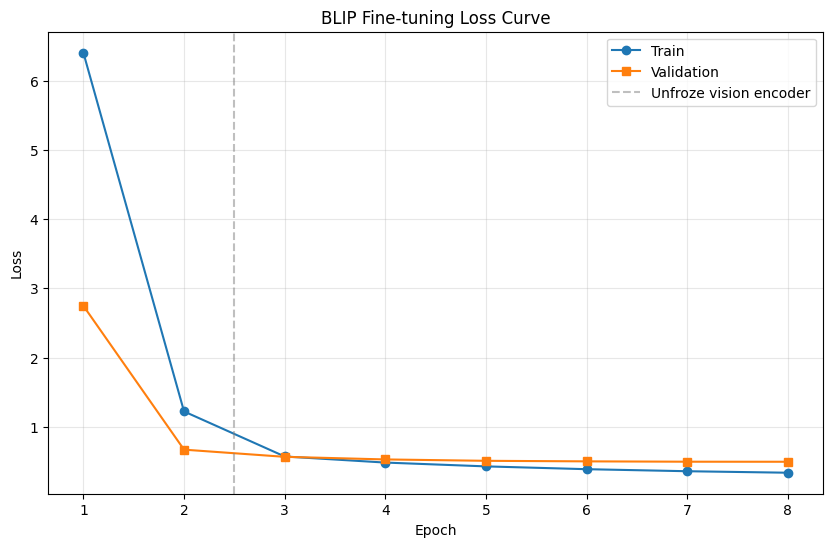

In [15]:
plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Train')
plt.plot(range(1, len(val_losses)+1),   val_losses,   marker='s', label='Validation')
plt.axvline(FREEZE_VISION_EPOCHS + 0.5, color='gray', linestyle='--', alpha=0.5,
            label='Unfroze vision encoder')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BLIP Fine-tuning Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 16. Load best checkpoint

In [16]:
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f" Loaded best model (epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")

 Loaded best model (epoch 8, val_loss=0.4964)


## 17. Hàm sinh caption (beam search)

BLIP hỗ trợ sẵn beam search. Beam size = 4 thường cho kết quả tốt hơn greedy mà không quá chậm.

 Ground Truth (raw)   :
 Stable enlargement of the cardiac silhouette, lateral view interlobar fissural thickening. Interstitial opacities greatest in the central lungs and bases.

 Ground Truth (clean) :
 Stable enlargement of the cardiac silhouette, lateral view interlobar fissural thickening. Interstitial opacities greatest in the central lungs and bases.

 Generated (raw)      :
 the cardiomediastinal silhouette is normal in size and contour. no focal consolidation, pneumothorax or large pleural effusion. negative for acute bone abnormality.

 Generated (clean)    :
 the cardiomediastinal silhouette is normal in size and contour. no focal consolidation, pneumothorax or large pleural effusion. negative for acute bone abnormality.


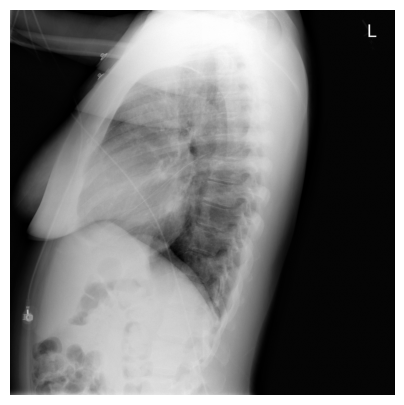

In [17]:
@torch.no_grad()
def generate_caption(image_path, num_beams=4, max_length=128):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)
    out = model.generate(
        **inputs,
        max_length=max_length,
        num_beams=num_beams,
        early_stopping=True,
        no_repeat_ngram_size=3,    # tránh lặp
    )
    return processor.decode(out[0], skip_special_tokens=True)


# ===== Hàm clean placeholder XXXX của dataset Indiana =====
# Dataset gốc đã ẩn danh các thông tin nhạy cảm (tên, ngày, ID...) bằng "XXXX"
# theo chuẩn HIPAA. Sau khi BLIP tokenizer lowercase -> "xxxx".
# Model học theo nên cũng sinh ra "xxxx" trong output -> cần xoá khi hiển thị.
import re

def clean_xxxx(text: str) -> str:
    """Xoá các placeholder xxxx/XXXX và dọn dẹp khoảng trắng + dấu câu thừa."""
    if not isinstance(text, str):
        return text
    # 1) Xoá các chuỗi x lặp >= 2 lần (xx, xxx, xxxx, XXXX...)
    text = re.sub(r"\b[xX]{2,}\b", "", text)
    # 2) Dọn khoảng trắng thừa
    text = re.sub(r"\s+", " ", text)
    # 3) Dọn khoảng trắng trước dấu câu (vd "have  ." -> "have.")
    text = re.sub(r"\s+([.,;:!?])", r"\1", text)
    # 4) Dọn dấu câu lặp (vd ".." -> ".", ", ," -> ",")
    text = re.sub(r"([.,;:!?])\s*\1+", r"\1", text)
    return text.strip()


# Test trên 1 ảnh
sample_path = test_df.iloc[0]["image_path"]
raw_pred = generate_caption(sample_path)

print(" Ground Truth (raw)   :\n", test_df.iloc[0]["findings"])
print("\n Ground Truth (clean) :\n", clean_xxxx(test_df.iloc[0]["findings"]))
print("\n Generated (raw)      :\n", raw_pred)
print("\n Generated (clean)    :\n", clean_xxxx(raw_pred))

plt.figure(figsize=(5,5))
plt.imshow(Image.open(sample_path), cmap='gray')
plt.axis('off')
plt.show()

## 18. Sinh prediction cho toàn bộ test set

Để tăng tốc, ta dùng batch generation thay vì gọi từng ảnh một.

In [18]:
@torch.no_grad()
def generate_batch(image_paths, num_beams=4, max_length=128):
    images = [Image.open(p).convert("RGB") for p in image_paths]
    inputs = processor(images=images, return_tensors="pt").to(DEVICE)
    out = model.generate(
        **inputs,
        max_length=max_length,
        num_beams=num_beams,
        early_stopping=True,
        no_repeat_ngram_size=3,
    )
    return [processor.decode(o, skip_special_tokens=True) for o in out]

predictions = []
GEN_BATCH = 8
for i in tqdm(range(0, len(test_df), GEN_BATCH), desc="Generating"):
    paths = test_df.iloc[i:i+GEN_BATCH]["image_path"].tolist()
    preds = generate_batch(paths)
    predictions.extend(preds)

print(f" Generated {len(predictions)} predictions")

# Lưu ra file để khỏi sinh lại nếu chạy metric nhiều lần
import json
with open(os.path.join(SAVE_DIR, "test_predictions.json"), "w") as f:
    json.dump({"refs": test_df["findings"].tolist(), "preds": predictions}, f)

Generating:   0%|          | 0/42 [00:00<?, ?it/s]

 Generated 334 predictions


## 19. Đánh giá: BLEU, ROUGE-L, METEOR, BERTScore

### 19.0 Làm sạch placeholder `xxxx` trước khi tính metric

Dataset Indiana University Chest X-rays đã ẩn danh thông tin nhạy cảm bằng token `XXXX` (theo chuẩn HIPAA), nên cả ground-truth lẫn output của model đều có rất nhiều `xxxx`. Nếu để nguyên:
- BLEU/ROUGE bị **inflated** (vì `xxxx` match `xxxx` cũng được tính là đúng).
- Hiển thị qualitative trông rất xấu.

Giải pháp: xoá `xxxx` khỏi **cả `refs_text` và `preds_text`** (và cả `predictions` để dùng ở phần qualitative bên dưới).

In [19]:
# Áp dụng clean_xxxx cho TẤT CẢ:
#  - predictions  (dùng ở phần qualitative + lưu file)
#  - refs_text & preds_text (dùng ở phần metrics ngay dưới đây)

# Lưu bản raw để so sánh nếu cần
predictions_raw = list(predictions)
predictions     = [clean_xxxx(p) for p in predictions]

refs_text_raw  = test_df["findings"].tolist()
preds_text_raw = predictions_raw

refs_text  = [clean_xxxx(r) for r in refs_text_raw]
preds_text = predictions  # đã clean ở trên

# Lọc ra các cặp mà sau khi clean vẫn còn nội dung (tránh chuỗi rỗng làm crash metric)
keep_idx = [i for i, (r, p) in enumerate(zip(refs_text, preds_text))
            if r.strip() and p.strip()]
refs_text  = [refs_text[i]  for i in keep_idx]
preds_text = [preds_text[i] for i in keep_idx]

print(f" Số cặp dùng để eval: {len(refs_text)} / {len(predictions_raw)}")
print(f"\n Ví dụ trước/sau khi clean:")
print(f"   GT raw  : {refs_text_raw[0][:120]}...")
print(f"   GT clean: {refs_text[0][:120]}...")
print(f"   Pred raw  : {predictions_raw[0][:120]}...")
print(f"   Pred clean: {preds_text[0][:120]}...")

# Re-tokenize cho BLEU/METEOR sau khi clean
refs_tok  = [[r.lower().split()] for r in refs_text]
preds_tok = [p.lower().split() for p in preds_text]

 Số cặp dùng để eval: 334 / 334

 Ví dụ trước/sau khi clean:
   GT raw  : Stable enlargement of the cardiac silhouette, lateral view interlobar fissural thickening. Interstitial opacities greate...
   GT clean: Stable enlargement of the cardiac silhouette, lateral view interlobar fissural thickening. Interstitial opacities greate...
   Pred raw  : the cardiomediastinal silhouette is normal in size and contour. no focal consolidation, pneumothorax or large pleural ef...
   Pred clean: the cardiomediastinal silhouette is normal in size and contour. no focal consolidation, pneumothorax or large pleural ef...


In [20]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from bert_score import score as bertscore

import nltk
for resource in ["wordnet", "omw-1.4", "punkt", "punkt_tab"]:
    nltk.download(resource, quiet=True)

# Lưu ý: refs_text, preds_text, refs_tok, preds_tok đã được clean & tokenize
# ở cell ngay phía trên (sau khi xoá placeholder xxxx).
print(f" Eval trên {len(refs_text)} cặp (đã clean xxxx)")

 Eval trên 334 cặp (đã clean xxxx)


In [21]:
# === BLEU ===
smooth = SmoothingFunction().method1
bleu1 = corpus_bleu(refs_tok, preds_tok, weights=(1,0,0,0),         smoothing_function=smooth)
bleu4 = corpus_bleu(refs_tok, preds_tok, weights=(.25,.25,.25,.25), smoothing_function=smooth)
print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

BLEU-1: 0.3093
BLEU-4: 0.0967


In [22]:
# === ROUGE-L ===
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
rouge_scores = [scorer.score(r, p)["rougeL"].fmeasure
                for r, p in zip(refs_text, preds_text)]
rouge_l = float(np.mean(rouge_scores))
print(f"ROUGE-L: {rouge_l:.4f}")

ROUGE-L: 0.2983


In [23]:
# === METEOR ===
meteor_scores = [meteor_score([r[0]], p) for r, p in zip(refs_tok, preds_tok)]
meteor_avg = float(np.mean(meteor_scores))
print(f"METEOR: {meteor_avg:.4f}")

METEOR: 0.2601


In [24]:
# === BERTScore ===
P, R, F1 = bertscore(preds_text, refs_text, lang="en", verbose=True)
bert_f1 = F1.mean().item()
print(f"BERTScore F1: {bert_f1:.4f}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/6 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/6 [00:00<?, ?it/s]

done in 4.62 seconds, 72.36 sentences/sec
BERTScore F1: 0.8855


## 20. Tổng hợp & so sánh với baseline LSTM

Điền số liệu baseline (DenseNet+LSTM) từ notebook cũ vào dict `baseline` để vẽ comparison chart.

In [25]:
#  Sửa các số này theo kết quả notebook cũ của bạn
baseline = {
    "BLEU-1":    0.2426,
    "BLEU-4":    0.0552,
    "ROUGE-L":   0.2782,
    "METEOR":    0.2000,
    "BERTScore": 0.8689,
}

blip_results = {
    "BLEU-1":    bleu1,
    "BLEU-4":    bleu4,
    "ROUGE-L":   rouge_l,
    "METEOR":    meteor_avg,
    "BERTScore": bert_f1,
}

print(f"{'Metric':<12} {'Baseline':>10} {'BLIP':>10} {'Δ':>8}")
print("=" * 44)
for m in baseline:
    delta = blip_results[m] - baseline[m]
    arrow = "" if delta > 0 else ""
    print(f"{m:<12} {baseline[m]:>10.4f} {blip_results[m]:>10.4f} {arrow}{abs(delta):>6.4f}")

Metric         Baseline       BLIP        Δ
BLEU-1           0.2426     0.3093 0.0667
BLEU-4           0.0552     0.0967 0.0415
ROUGE-L          0.2782     0.2983 0.0201
METEOR           0.2000     0.2601 0.0601
BERTScore        0.8689     0.8855 0.0166


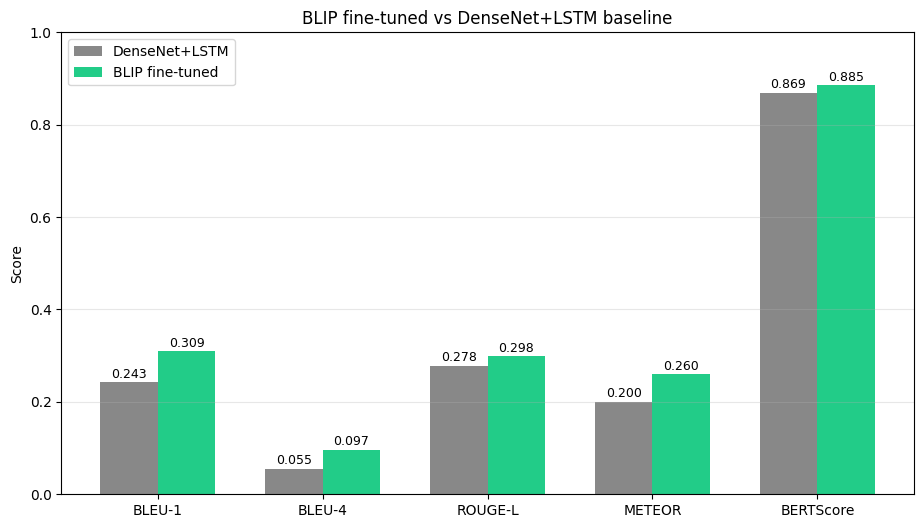

In [26]:
metrics = list(baseline.keys())
x = np.arange(len(metrics))
w = 0.35

plt.figure(figsize=(11, 6))
b1 = plt.bar(x - w/2, [baseline[m]      for m in metrics], w, label="DenseNet+LSTM", color="#888")
b2 = plt.bar(x + w/2, [blip_results[m]  for m in metrics], w, label="BLIP fine-tuned", color="#2c8")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("BLIP fine-tuned vs DenseNet+LSTM baseline")
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.3f}", ha='center', fontsize=9)
plt.show()

## 21. Hiển thị vài ví dụ định tính

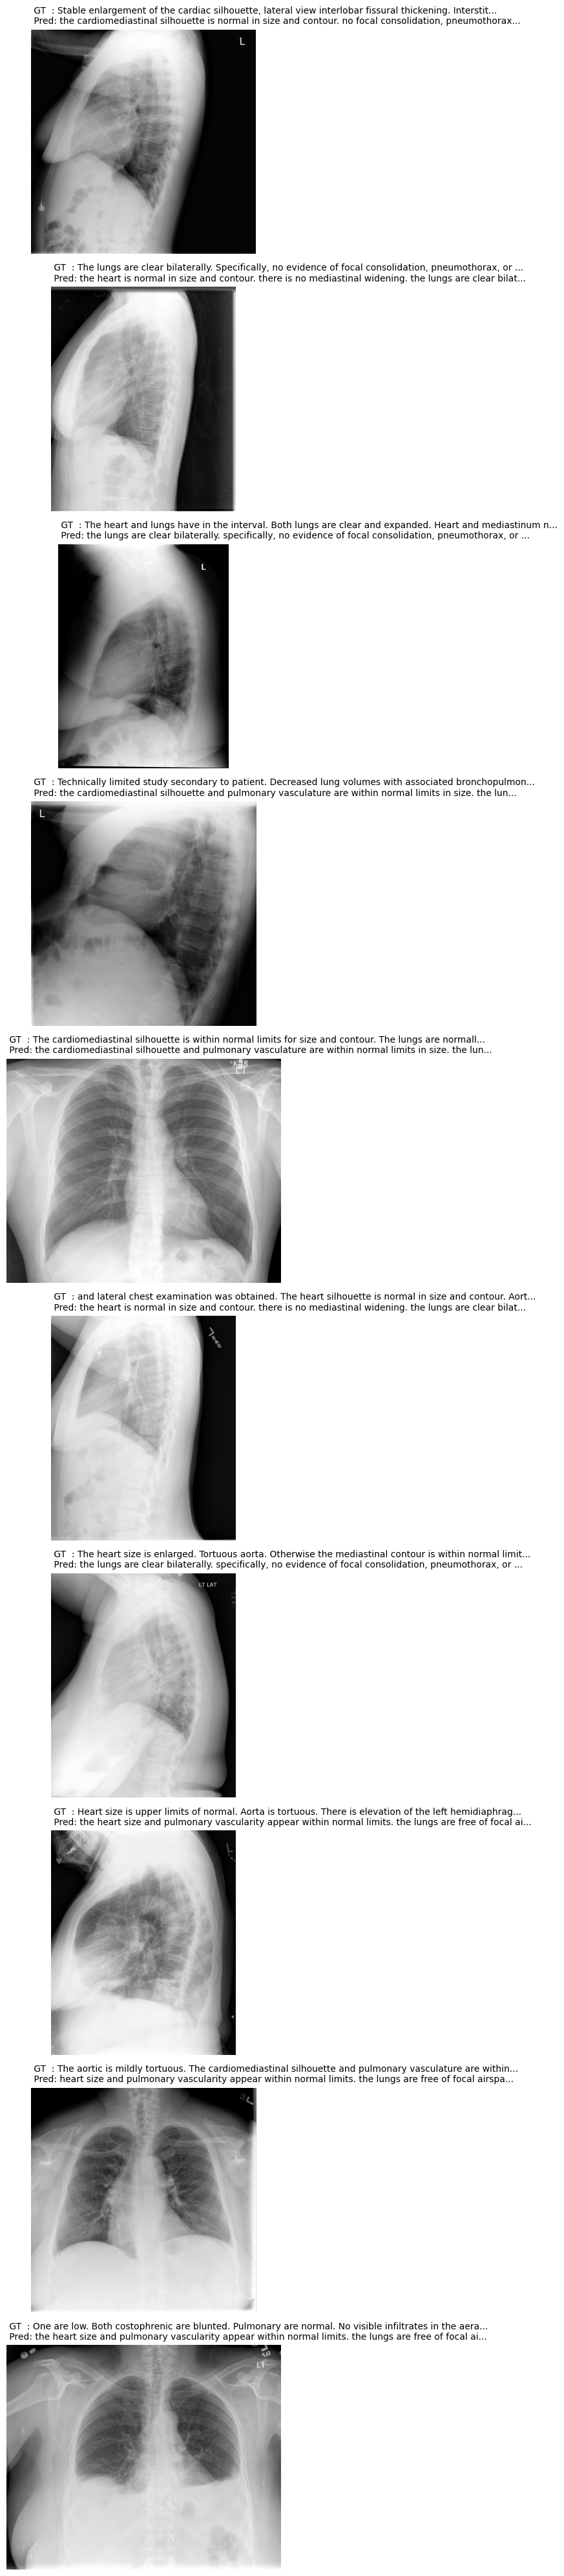

In [27]:
N_SHOW = 10
fig, axes = plt.subplots(N_SHOW, 1, figsize=(8, 4 * N_SHOW))
if N_SHOW == 1:
    axes = [axes]

for i in range(N_SHOW):
    ax = axes[i]
    img = Image.open(test_df.iloc[i]["image_path"])
    ax.imshow(img, cmap='gray')
    ax.axis('off')

    # Clean cả GT và prediction để hiển thị đẹp (không có xxxx)
    gt_clean   = clean_xxxx(test_df.iloc[i]["findings"])
    pred_clean = clean_xxxx(predictions_raw[i])  # dùng raw để khỏi double-clean

    ax.set_title(
        f" GT  : {gt_clean[:100]}...\n"
        f" Pred: {pred_clean[:100]}...",
        fontsize=10, loc='left'
    )

plt.tight_layout()
plt.show()

## 22. Lưu model & predictions cuối cùng

In [28]:
FINAL_DIR = os.path.join(SAVE_DIR, "final_blip")
model.save_pretrained(FINAL_DIR)
processor.save_pretrained(FINAL_DIR)
print(f" Saved  {FINAL_DIR}")
print("   Để load lại: ")
print(f"   model     = BlipForConditionalGeneration.from_pretrained('{FINAL_DIR}')")
print(f"   processor = BlipProcessor.from_pretrained('{FINAL_DIR}')")

 Saved  /content/drive/MyDrive/xray_blip/final_blip
   Để load lại: 
   model     = BlipForConditionalGeneration.from_pretrained('/content/drive/MyDrive/xray_blip/final_blip')
   processor = BlipProcessor.from_pretrained('/content/drive/MyDrive/xray_blip/final_blip')


## 23. (Tuỳ chọn) Demo tương tác — upload ảnh và sinh report

Saving images.jpeg to images.jpeg


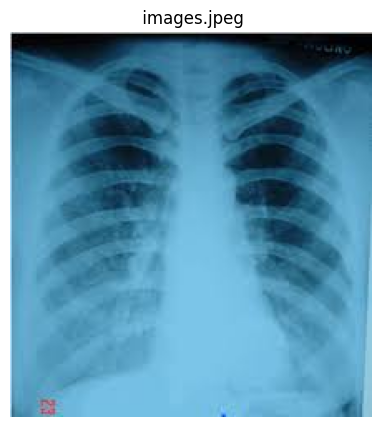

 Generated report:
the heart size and pulmonary vascularity appear within normal limits. the lungs are free of focal airspace disease. no pleural effusion or pneumothorax is seen.



In [29]:
from google.colab import files
import io

uploaded = files.upload()   # mở dialog chọn ảnh

for fname, fdata in uploaded.items():
    img = Image.open(io.BytesIO(fdata)).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model.generate(**inputs, max_length=128, num_beams=4,
                             early_stopping=True, no_repeat_ngram_size=3)
    caption = processor.decode(out[0], skip_special_tokens=True)

    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f" {fname}")
    plt.show()
    print(f" Generated report:\n{caption}\n")